# Validações Estatísticas do BeamNG como Digital Twin — v3

Correções desta versão:
- `posZ`: deriva do GPS removida com `scipy.signal.detrend`
- `vel`: real usa `Velocidade do veículo (km/h)` do OBD (melhor resolução que GPS); simulado suavizado com janela móvel de 1s
- `throttle`: removido da análise de correlação (mantido apenas no plot visual)
- `lag`: fixado em 0 para posZ e vel (cross-correlação gerava lags absurdos nesses sinais)
- `lag`: mantido automático apenas para posX e posY

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import correlate, detrend
from sklearn.preprocessing import MinMaxScaler
from os import listdir
import ast

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2. Funções auxiliares

In [2]:
def latlon_para_metros(lat, lon):
    R = 6_371_000.0
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    x = R * (lon_r - lon0) * np.cos(lat0)
    y = R * (lat_r - lat0)
    return x, y

def parse_vel(s):
    try:
        v = ast.literal_eval(str(s))
        return float(np.linalg.norm(v))
    except Exception:
        return np.nan

def pearson_sliding_window(x, y, janela=50):
    """Pearson vetorizado com stride_tricks."""
    n = len(x)
    r = np.full(n, np.nan)
    shape   = (n - janela + 1, janela)
    strides = (x.strides[0], x.strides[0])
    X = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
    Y = np.lib.stride_tricks.as_strided(y, shape=shape, strides=strides)
    Xm = X - X.mean(axis=1, keepdims=True)
    Ym = Y - Y.mean(axis=1, keepdims=True)
    num   = (Xm * Ym).sum(axis=1)
    denom = np.sqrt((Xm**2).sum(axis=1) * (Ym**2).sum(axis=1))
    with np.errstate(invalid='ignore'):
        r[janela - 1:] = np.where(denom > 1e-10, num / denom, np.nan)
    return r

## 3. Carregar dados

In [3]:
reais = []
for file in sorted(listdir('circuito4/real')):
    reais.append(pd.read_csv(f'circuito4/real/{file}', sep=',', skipinitialspace=True))
print(f"Reais carregados: {len(reais)}")

simulados = []
for file in sorted(listdir('circuito4/simulado_taxa_coleta_correta')):
    simulados.append(pd.read_csv(f'circuito4/simulado_taxa_coleta_correta/{file}', sep=';'))
print(f"Simulados carregados: {len(simulados)}")

Reais carregados: 10
Simulados carregados: 1


## 4. Preparação — REAL

In [4]:
def preparar_real(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.sort_values('Time (sec)').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['Time (sec)'], unit='s')
    df = df.set_index('time')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(axis=1, how='all')

    # GPS → metros
    lat = df['Latitude (deg)'].values
    lon = df['Longitude (deg)'].values
    x_m, y_m = latlon_para_metros(lat, lon)
    df['posX'] = x_m
    df['posY'] = y_m

    # posZ: altitude com deriva removida (detrend linear)
    alt = df['Altitude (m)'].values
    df['posZ'] = detrend(alt, type='linear')
    # ── NOTA: detrend remove a tendência linear de longo prazo (a deriva do GPS)
    # mantendo apenas as variações reais de altitude (subidas/descidas da pista)

    # throttle (referência visual, não entra na correlação)
    df = df.rename(columns={'Posição D do pedal do acelerador (%)': 'throttle'})

    # vel: usar velocidade OBD em vez de GPS
    # OBD tem resolução ~1Hz mas é muito mais precisa que o GPS para velocidade
    if 'Velocidade do veículo (km/h)' in df.columns:
        df['vel'] = df['Velocidade do veículo (km/h)'] / 3.6   # km/h → m/s
    elif 'Velocidade do GPS (km/h)' in df.columns:
        print("AVISO: velocidade OBD não encontrada, usando GPS como fallback")
        df['vel'] = df['Velocidade do GPS (km/h)'] / 3.6

    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df

real = preparar_real(reais[0])
print(f"Real → {len(real)} amostras | duração: {real.index[-1]}")

Real → 4430 amostras | duração: 0 days 00:07:22.900000


## 5. Preparação — SIMULADO

In [5]:
def preparar_simulado(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    time_col = df.columns[0]
    df = df.rename(columns={time_col: 'time'})
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = df['time'] - df['time'].iloc[0]
    df['time'] = pd.to_timedelta(df['time'], unit='s')
    df = df.set_index('time')

    # vel: lista string → norma euclidiana
    if 'vel' in df.columns:
        df['vel'] = df['vel'].apply(parse_vel)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(axis=1, how='all')

    # posZ: remover deriva (consistência com o real)
    if 'posZ' in df.columns:
        df['posZ'] = detrend(df['posZ'].values, type='linear')

    df = df.resample(freq).mean().interpolate(method='time')

    # vel simulado: suavizar com janela móvel de 1s (10 amostras @ 10Hz)
    # equipara a resolução temporal com a velocidade OBD do real (~1Hz)
    if 'vel' in df.columns:
        df['vel'] = df['vel'].rolling(window=10, center=True, min_periods=1).mean()

    df.index = df.index - df.index[0]
    return df

simulado = preparar_simulado(simulados[0])
print(f"Simulado → {len(simulado)} amostras | duração: {simulado.index[-1]}")

Simulado → 4505 amostras | duração: 0 days 00:07:30.400000


## 6. Selecionar colunas e cortar duração mínima

In [6]:
# throttle: apenas visual, NÃO entra na análise de correlação
colunas_plot = ['throttle', 'posX', 'posY', 'posZ', 'vel']
colunas_corr = ['posX', 'posY', 'posZ', 'vel']   # <- análise estatística

# Verificar disponibilidade
for col in colunas_plot:
    ok_r = col in real.columns
    ok_s = col in simulado.columns
    role = '(só visual)' if col == 'throttle' else '(correlação)'
    print(f"{'✓' if (ok_r and ok_s) else '✗'} {col:10s} {role}  real={'OK' if ok_r else 'FALTA'}  simulado={'OK' if ok_s else 'FALTA'}")

duracao_min = min(real.index[-1], simulado.index[-1])
real_plot     = real.loc[:duracao_min, [c for c in colunas_plot if c in real.columns]]
simulado_plot = simulado.loc[:duracao_min, [c for c in colunas_plot if c in simulado.columns]]
real_corr     = real.loc[:duracao_min, colunas_corr]
simulado_corr = simulado.loc[:duracao_min, colunas_corr]

print(f"\nDuração comum: {duracao_min}")

✓ throttle   (só visual)  real=OK  simulado=OK
✓ posX       (correlação)  real=OK  simulado=OK
✓ posY       (correlação)  real=OK  simulado=OK
✓ posZ       (correlação)  real=OK  simulado=OK
✓ vel        (correlação)  real=OK  simulado=OK

Duração comum: 0 days 00:07:22.900000


## 7. Normalização e junção

In [7]:
def normalizar_minmax(df, cols):
    scaler = MinMaxScaler()
    arr = scaler.fit_transform(df[cols])
    return pd.DataFrame(arr, index=df.index, columns=cols)

# Para plots: normalizar todas as colunas visuais
cols_plot_r = [c for c in colunas_plot if c in real_plot.columns]
cols_plot_s = [c for c in colunas_plot if c in simulado_plot.columns]
real_norm_plot = normalizar_minmax(real_plot, cols_plot_r)
sim_norm_plot  = normalizar_minmax(simulado_plot, cols_plot_s)

# Para correlação: normalizar só as colunas de análise
real_norm = normalizar_minmax(real_corr, colunas_corr)
sim_norm  = normalizar_minmax(simulado_corr, colunas_corr)

df_corr = pd.concat(
    [real_norm.add_prefix('real_'), sim_norm.add_prefix('sim_')],
    axis=1, join='inner'
).dropna()

df_plot = pd.concat(
    [real_norm_plot.add_prefix('real_'), sim_norm_plot.add_prefix('sim_')],
    axis=1, join='inner'
).dropna()

print(f"Shape correlação: {df_corr.shape} | Shape plot: {df_plot.shape}")

Shape correlação: (4430, 8) | Shape plot: (4430, 10)


## 8. Plot das séries normalizadas (todas as variáveis incluindo throttle)

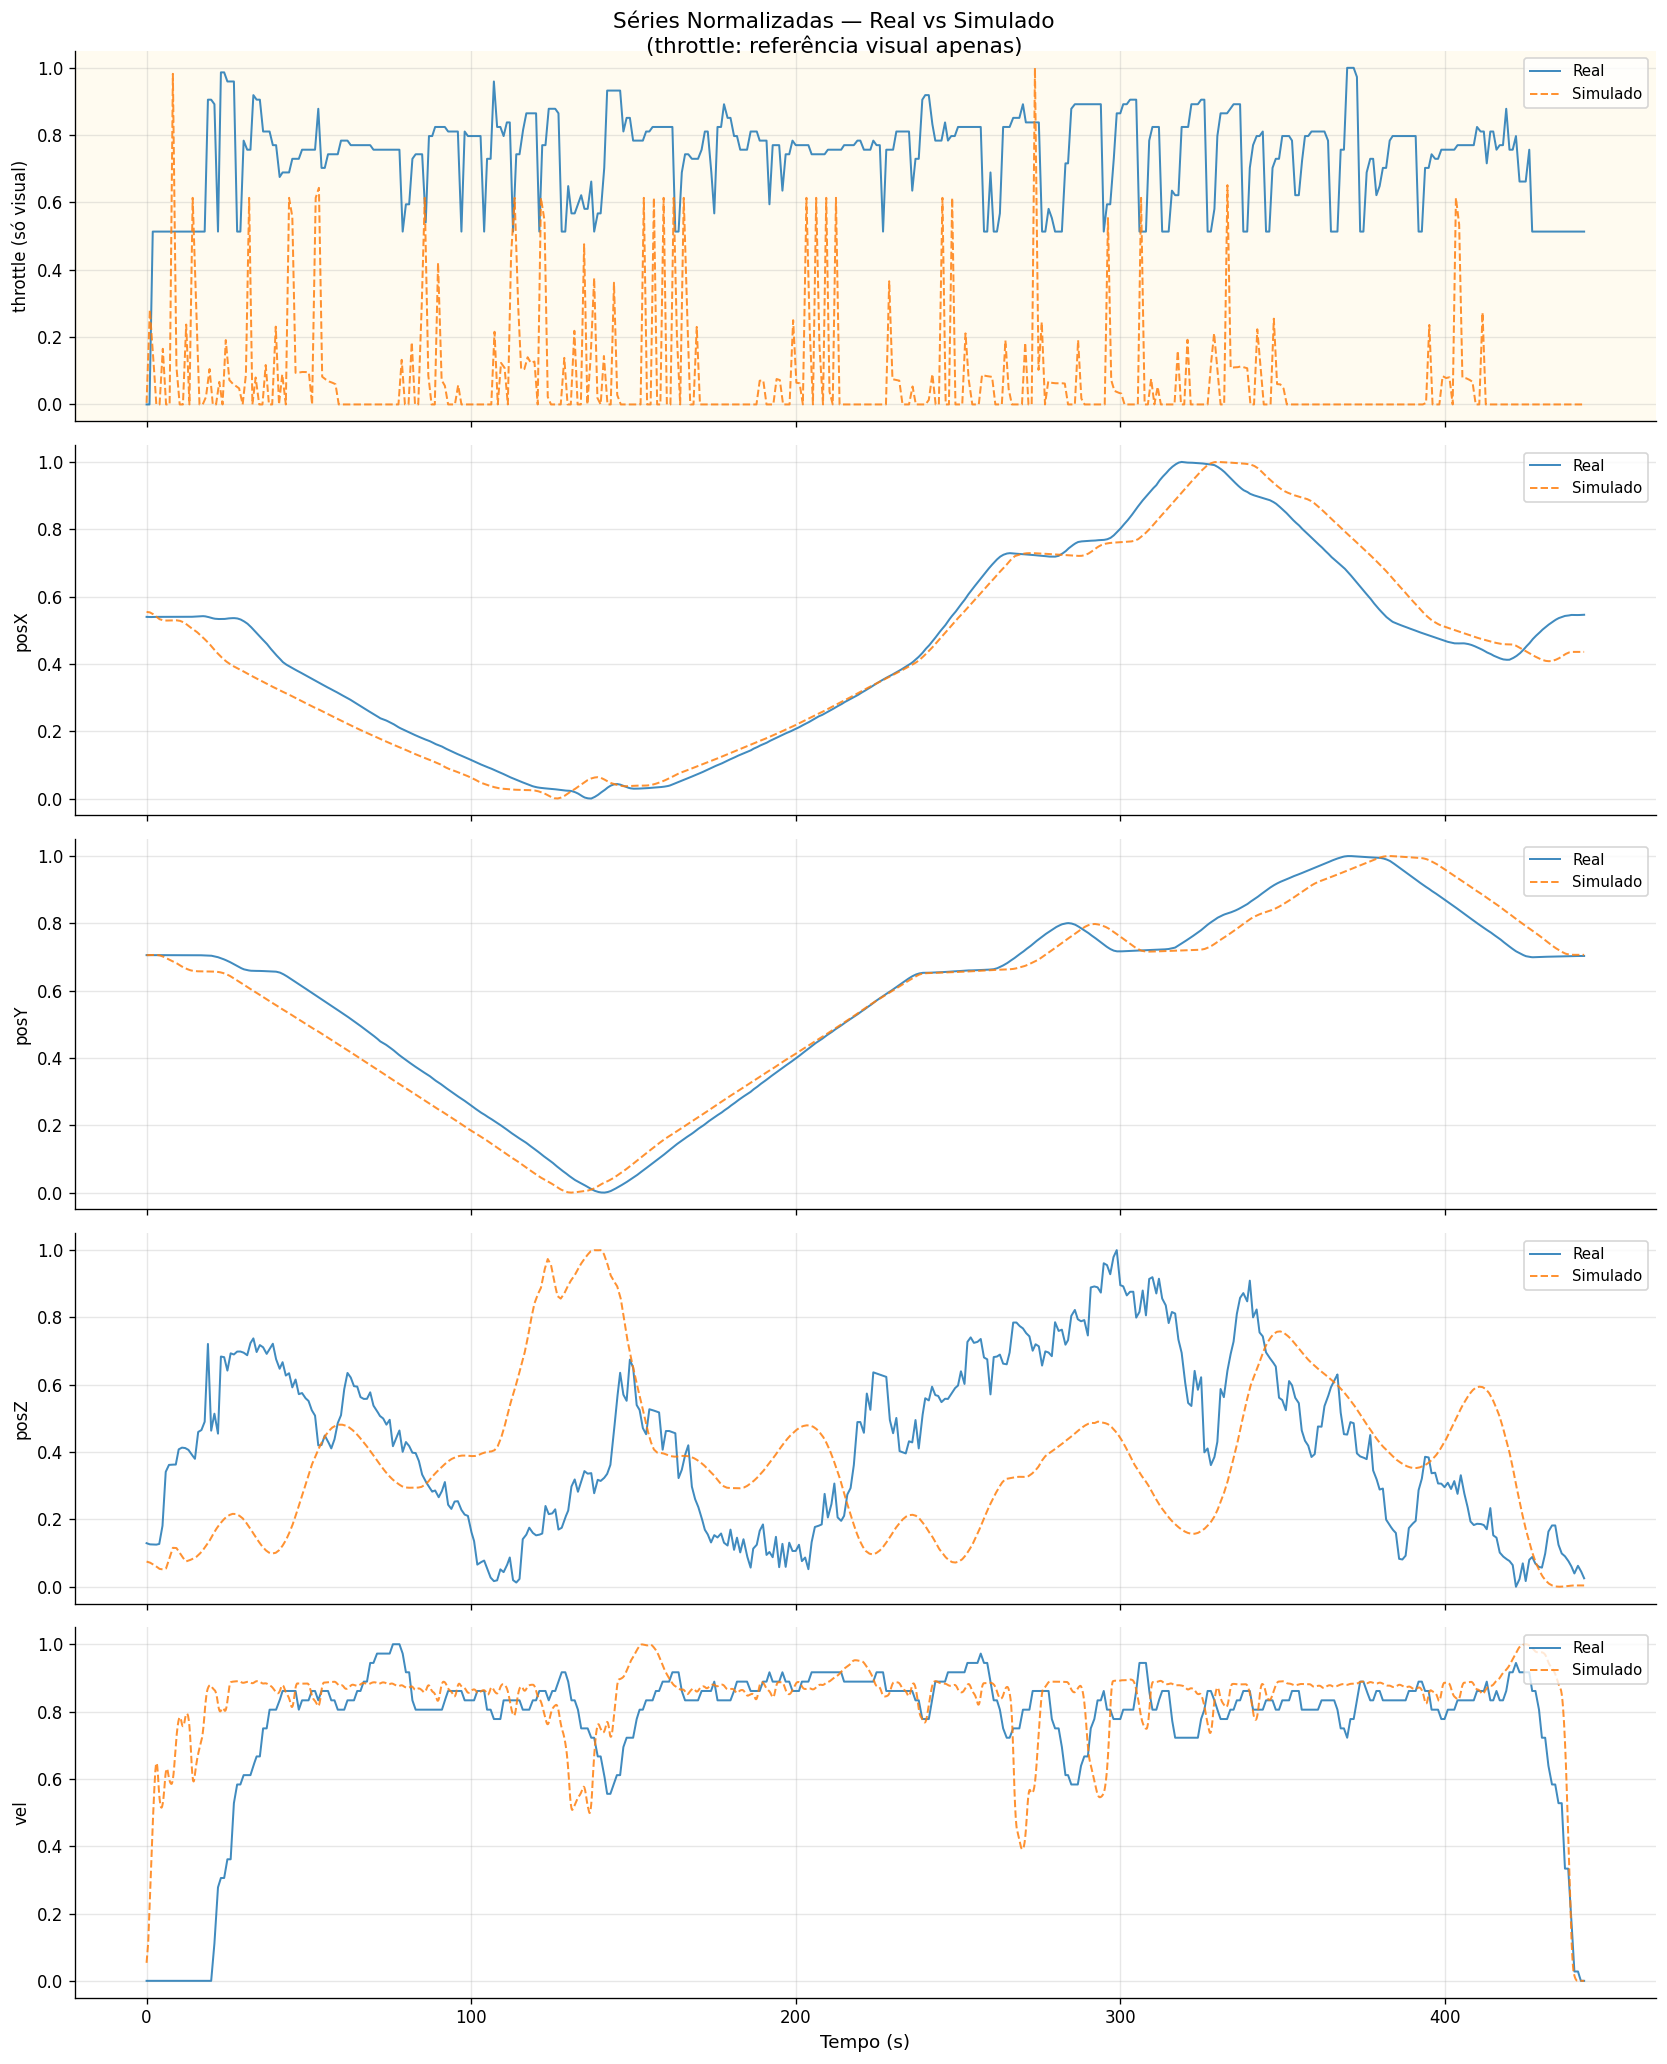

In [8]:
t_plot = df_plot.index.total_seconds()
cols_vis = [c for c in colunas_plot if f'real_{c}' in df_plot.columns]

fig, axes = plt.subplots(len(cols_vis), 1, figsize=(14, 3.5 * len(cols_vis)), sharex=True)
if len(cols_vis) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_vis):
    ax.plot(t_plot, df_plot[f'real_{col}'], label='Real',     color='#1f77b4', lw=1.2, alpha=0.85)
    ax.plot(t_plot, df_plot[f'sim_{col}'],  label='Simulado', color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')
    label = col + (' (só visual)' if col == 'throttle' else '')
    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    if col == 'throttle':
        ax.set_facecolor('#fffbf0')   # fundo levemente amarelo para indicar "só visual"

axes[-1].set_xlabel('Tempo (s)', fontsize=11)
fig.suptitle('Séries Normalizadas — Real vs Simulado\n(throttle: referência visual apenas)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Trajetória espacial

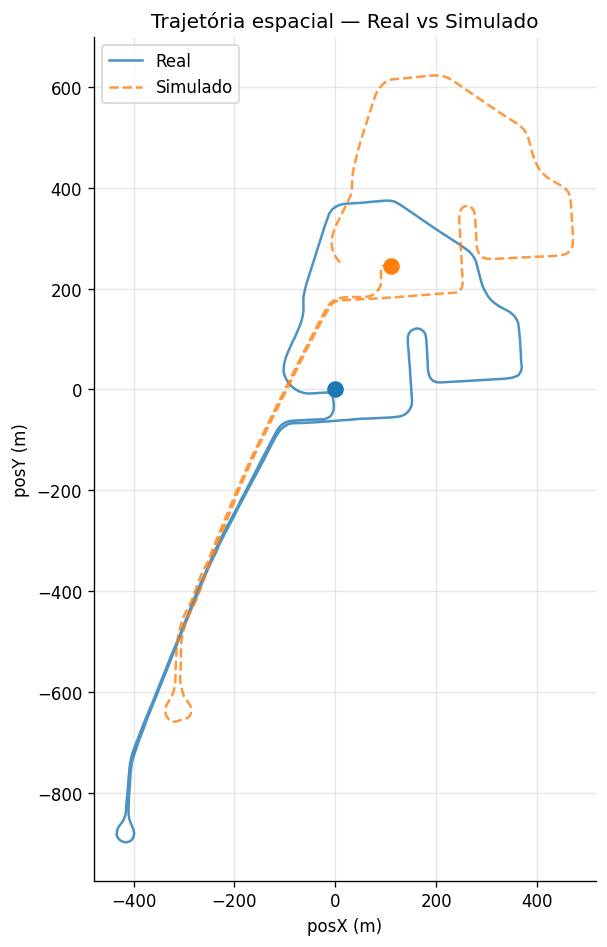

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(real_corr['posX'],     real_corr['posY'],     label='Real',     color='#1f77b4', lw=1.5, alpha=0.8)
ax.plot(simulado_corr['posX'], simulado_corr['posY'], label='Simulado', color='#ff7f0e', lw=1.5, alpha=0.8, ls='--')
ax.scatter(real_corr['posX'].iloc[0],     real_corr['posY'].iloc[0],     color='#1f77b4', s=80, zorder=5)
ax.scatter(simulado_corr['posX'].iloc[0], simulado_corr['posY'].iloc[0], color='#ff7f0e', s=80, zorder=5)
ax.set_xlabel('posX (m)')
ax.set_ylabel('posY (m)')
ax.set_title('Trajetória espacial — Real vs Simulado')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 10. Detecção de LAG — apenas posX e posY

> `posZ` e `vel` usam `lag=0` fixo — a cross-correlação gerava lags fisicamente impossíveis
> nesses sinais por causa da deriva do GPS e da diferença de fonte de velocidade.

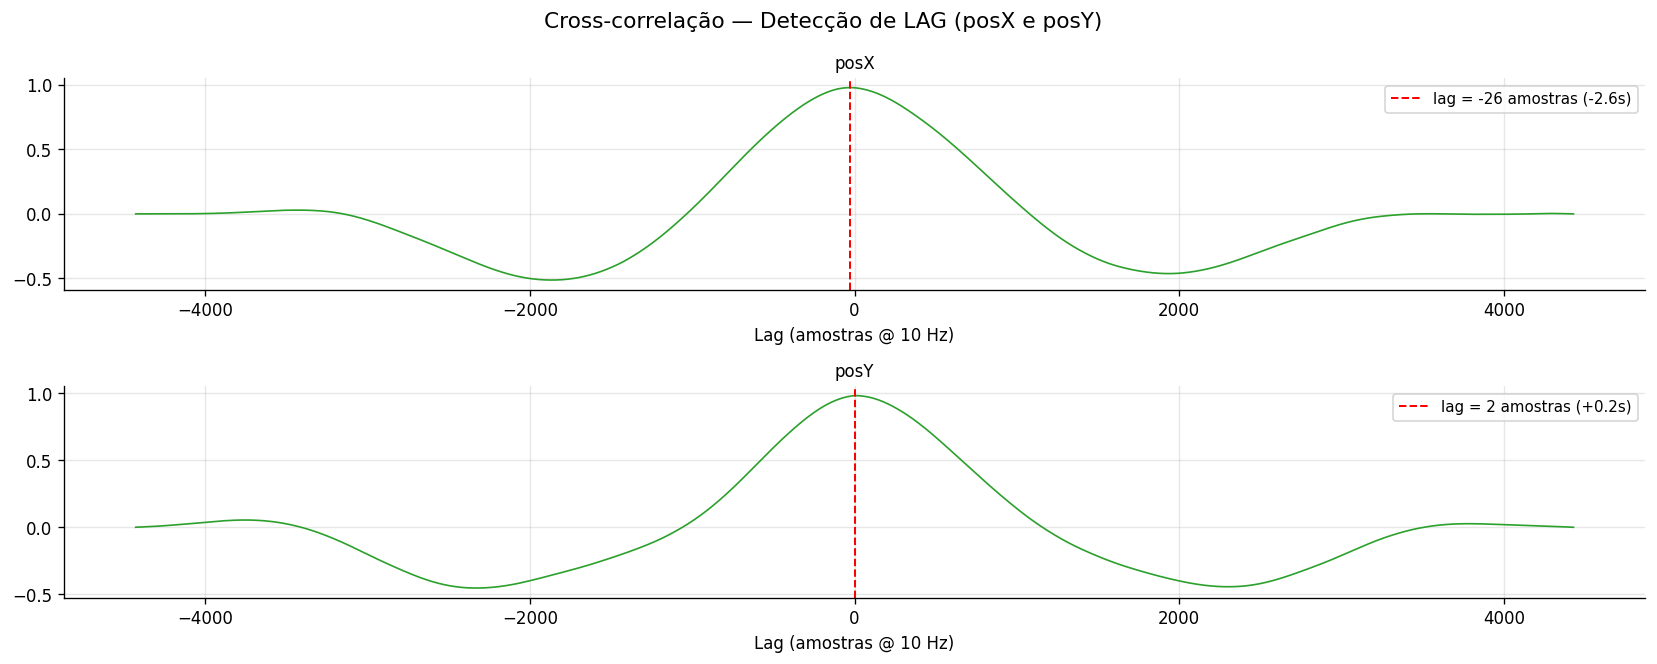


Lags aplicados:
  posX      : -26 amostras = -2.6s  [automático]
  posY      : +2 amostras = +0.2s  [automático]
  posZ      : +0 amostras = +0.0s  [fixo (0)]
  vel       : +0 amostras = +0.0s  [fixo (0)]


In [10]:
# Lags: automático para posX/posY, fixo em 0 para posZ e vel
LAGS_FIXOS = {'posZ': 0, 'vel': 0}
lags = {}

colunas_lag_auto = ['posX', 'posY']

fig, axes = plt.subplots(len(colunas_lag_auto), 1, figsize=(14, 2.8 * len(colunas_lag_auto)))
if len(colunas_lag_auto) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas_lag_auto):
    x = df_corr[f'real_{col}'].values
    y = df_corr[f'sim_{col}'].values

    corr      = correlate(x - x.mean(), y - y.mean(), mode='full')
    norm_denom = np.std(x) * np.std(y) * len(x)
    corr      = corr / norm_denom if norm_denom > 0 else corr

    lag_range = np.arange(-(len(x) - 1), len(x))
    lag_opt   = int(lag_range[np.argmax(corr)])
    lags[col] = lag_opt

    ax.plot(lag_range, corr, lw=1, color='#2ca02c')
    ax.axvline(lag_opt, color='red', ls='--', lw=1.2,
               label=f'lag = {lag_opt} amostras ({lag_opt * 0.1:+.1f}s)')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlabel('Lag (amostras @ 10 Hz)')

# Adicionar lags fixos
for col, lag in LAGS_FIXOS.items():
    lags[col] = lag

fig.suptitle('Cross-correlação — Detecção de LAG (posX e posY)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nLags aplicados:")
for col in colunas_corr:
    fonte = 'automático' if col in colunas_lag_auto else 'fixo (0)'
    print(f"  {col:10s}: {lags[col]:+d} amostras = {lags[col] * 0.1:+.1f}s  [{fonte}]")

In [11]:
for col, lag in lags.items():
    df_corr[f'sim_{col}_shifted'] = df_corr[f'sim_{col}'].shift(lag)

df_corr = df_corr.dropna()
print(f"Shape após shift: {df_corr.shape}")

Shape após shift: (4402, 12)


## 11. Correlação de Pearson global

In [12]:
resultados_pearson = {}

print(f"{'Coluna':<12} {'r (sem lag)':>12} {'p-value':>12} {'r (com lag)':>12} {'p-value':>12}")
print("-" * 65)

for col in colunas_corr:
    x  = df_corr[f'real_{col}'].values
    y  = df_corr[f'sim_{col}'].values
    ys = df_corr[f'sim_{col}_shifted'].values

    r_raw,   p_raw   = pearsonr(x, y)
    r_shift, p_shift = pearsonr(x, ys)

    resultados_pearson[col] = dict(r_raw=r_raw, p_raw=p_raw, r_shift=r_shift, p_shift=p_shift)
    print(f"{col:<12} {r_raw:>12.4f} {p_raw:>12.2e} {r_shift:>12.4f} {p_shift:>12.2e}")

Coluna        r (sem lag)      p-value  r (com lag)      p-value
-----------------------------------------------------------------
posX               0.9778     0.00e+00       0.9793     0.00e+00
posY               0.9814     0.00e+00       0.9815     0.00e+00
posZ              -0.0885     4.05e-09      -0.0885     4.05e-09
vel                0.4672    1.29e-237       0.4672    1.29e-237


## 12. Pearson com Janela Deslizante

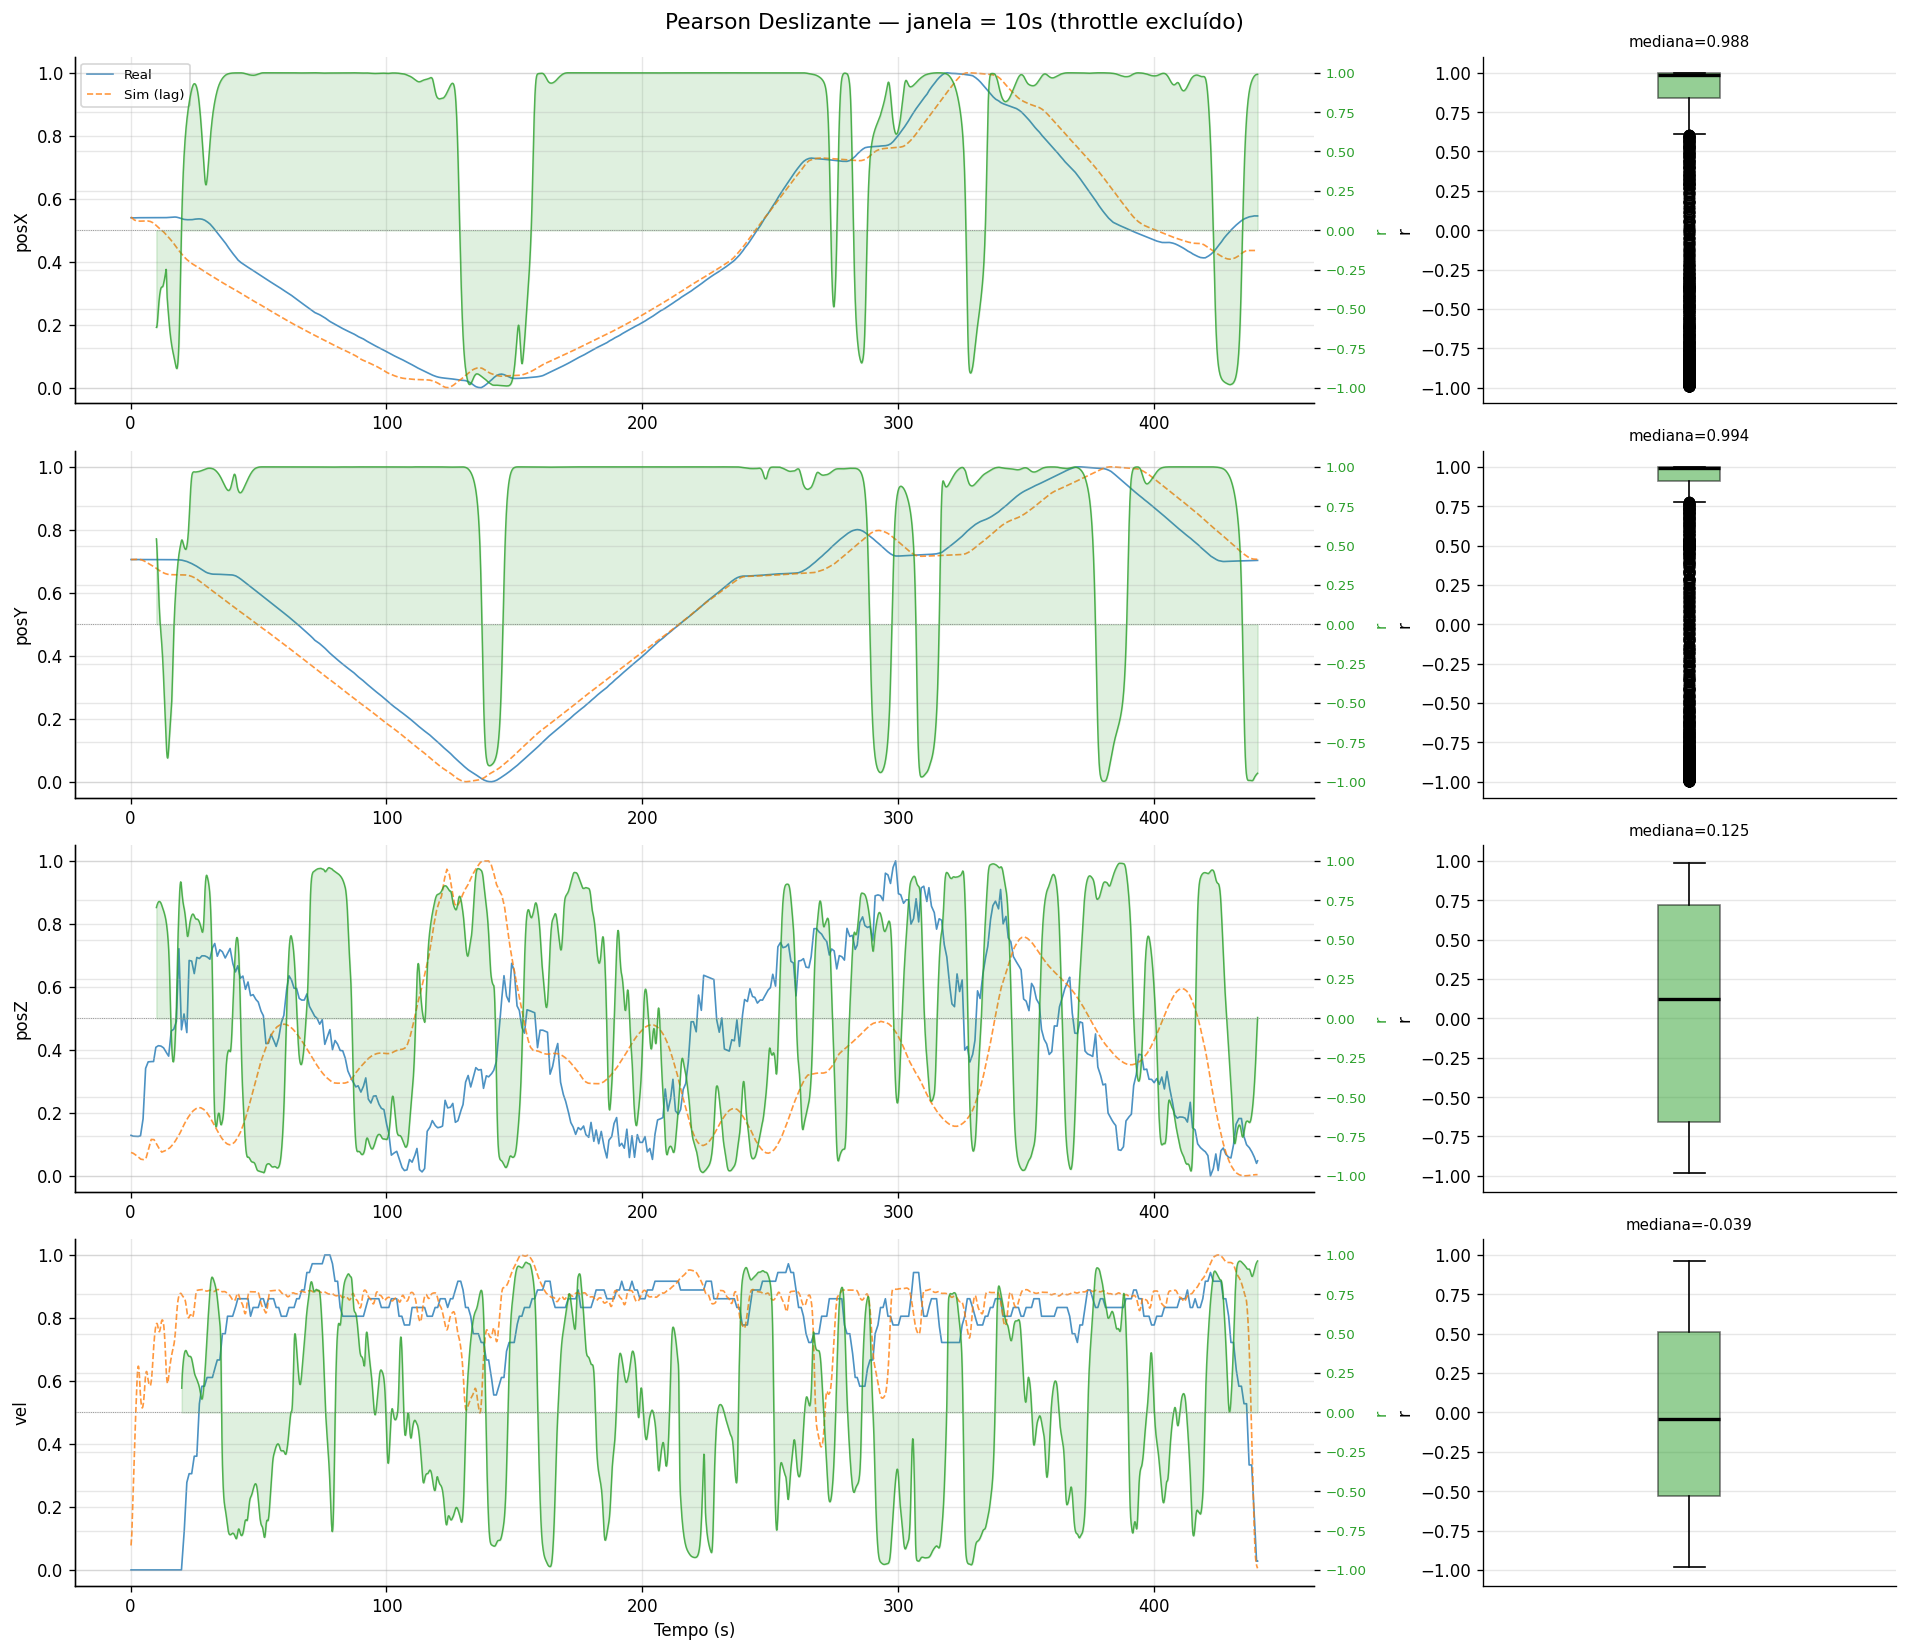

In [13]:
JANELA_S   = 10
FREQ_HZ    = 10
janela_pts = JANELA_S * FREQ_HZ

t = df_corr.index.total_seconds().values

fig, axes = plt.subplots(
    len(colunas_corr), 2, figsize=(16, 3.5 * len(colunas_corr)),
    gridspec_kw={'width_ratios': [3, 1]}
)

for i, col in enumerate(colunas_corr):
    x  = df_corr[f'real_{col}'].values
    ys = df_corr[f'sim_{col}_shifted'].values
    r_slide = pearson_sliding_window(x, ys, janela=janela_pts)

    ax_ts  = axes[i][0]
    ax_box = axes[i][1]

    ax_ts.plot(t, x,  label='Real',      color='#1f77b4', lw=1.0, alpha=0.8)
    ax_ts.plot(t, ys, label='Sim (lag)', color='#ff7f0e', lw=1.0, alpha=0.8, ls='--')

    ax2 = ax_ts.twinx()
    ax2.fill_between(t, r_slide, alpha=0.15, color='#2ca02c', where=~np.isnan(r_slide))
    ax2.plot(t, r_slide, color='#2ca02c', lw=0.9, alpha=0.8)
    ax2.set_ylim(-1.1, 1.1)
    ax2.set_ylabel('r', color='#2ca02c', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#2ca02c', labelsize=8)
    ax2.axhline(0, color='gray', lw=0.5, ls=':')

    ax_ts.set_ylabel(col, fontsize=10)
    ax_ts.set_ylim(-0.05, 1.05)
    if i == 0:
        ax_ts.legend(loc='upper left', fontsize=8)
    if i == len(colunas_corr) - 1:
        ax_ts.set_xlabel('Tempo (s)')

    r_valid = r_slide[~np.isnan(r_slide)]
    ax_box.boxplot(r_valid, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#2ca02c', alpha=0.5),
                   medianprops=dict(color='black', lw=2))
    ax_box.set_ylim(-1.1, 1.1)
    ax_box.set_ylabel('r')
    ax_box.set_xticks([])
    ax_box.set_title(f'mediana={np.median(r_valid):.3f}', fontsize=9)

fig.suptitle(f'Pearson Deslizante — janela = {JANELA_S}s (throttle excluído)', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Heatmap de Pearson

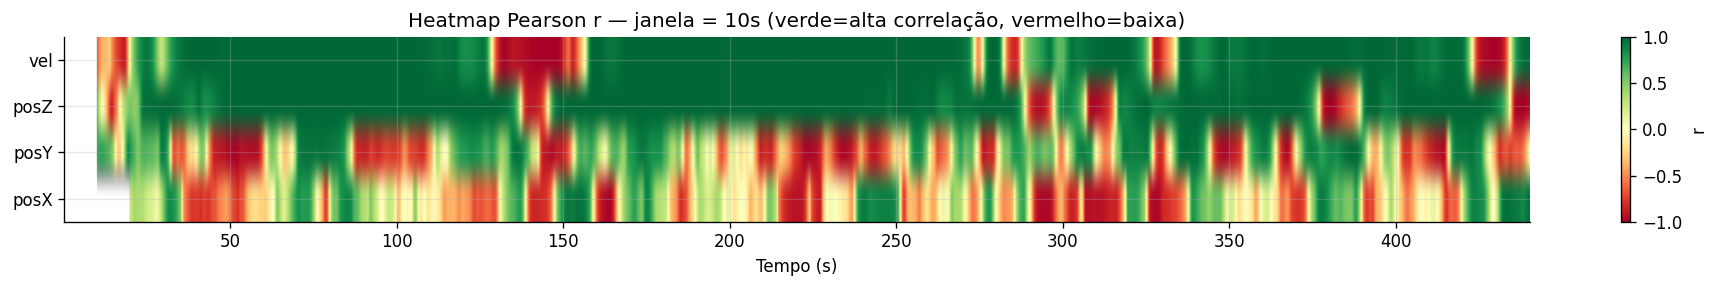

In [14]:
matriz_r = np.vstack([
    pearson_sliding_window(
        df_corr[f'real_{col}'].values,
        df_corr[f'sim_{col}_shifted'].values,
        janela=janela_pts
    )
    for col in colunas_corr
])

fig, ax = plt.subplots(figsize=(16, 2.5))
im = ax.imshow(
    matriz_r, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1,
    extent=[t[0], t[-1], -0.5, len(colunas_corr) - 0.5]
)
ax.set_yticks(range(len(colunas_corr)))
ax.set_yticklabels(colunas_corr)
ax.set_xlabel('Tempo (s)')
ax.set_title(f'Heatmap Pearson r — janela = {JANELA_S}s (verde=alta correlação, vermelho=baixa)')
plt.colorbar(im, ax=ax, label='r')
plt.tight_layout()
plt.show()

## 14. Resumo final

In [15]:
print("=" * 65)
print("RESUMO — REAL × SIMULADO BeamNG Digital Twin — v3")
print("=" * 65)
print(f"{'Variável':<10} {'r_global':>9} {'r_mediana':>10} {'lag (s)':>9}  Nota")
print("-" * 65)

notas = {
    'posX': 'lag automático',
    'posY': 'lag automático',
    'posZ': 'detrend aplicado + lag=0',
    'vel':  'OBD + suavização 1s + lag=0',
}

for col in colunas_corr:
    r_global = resultados_pearson[col]['r_shift']
    r_slide  = pearson_sliding_window(
        df_corr[f'real_{col}'].values,
        df_corr[f'sim_{col}_shifted'].values,
        janela=janela_pts
    )
    r_med = np.nanmedian(r_slide)
    lag_s = lags[col] * 0.1
    print(f"{col:<10} {r_global:>9.4f} {r_med:>10.4f} {lag_s:>+9.1f}s  {notas.get(col,'')}")

print("=" * 65)
print("throttle: excluído da correlação (depende do motorista, não do veículo)")
print("=" * 65)

RESUMO — REAL × SIMULADO BeamNG Digital Twin — v3
Variável    r_global  r_mediana   lag (s)  Nota
-----------------------------------------------------------------
posX          0.9793     0.9879      -2.6s  lag automático
posY          0.9815     0.9939      +0.2s  lag automático
posZ         -0.0885     0.1245      +0.0s  detrend aplicado + lag=0
vel           0.4672    -0.0391      +0.0s  OBD + suavização 1s + lag=0
throttle: excluído da correlação (depende do motorista, não do veículo)
